This notebook illustrates the ``ConvexHull`` of ``scipy.spatial`` for the
planar convex hull problem.

In [1]:
import numpy as np
from scipy.spatial import ConvexHull, convex_hull_plot_2d
from matplotlib import pyplot as plt

We generate 20 points at random in the plane.

In [2]:
points = np.random.rand(20, 2)
points

array([[0.20440449, 0.49189056],
       [0.8168082 , 0.33483765],
       [0.26217467, 0.19615764],
       [0.34526909, 0.03178936],
       [0.33855927, 0.44635535],
       [0.82586431, 0.10754144],
       [0.93374879, 0.73453368],
       [0.81416099, 0.083116  ],
       [0.23836932, 0.28602977],
       [0.37031061, 0.73541446],
       [0.29514181, 0.3584959 ],
       [0.15504286, 0.58038739],
       [0.7971545 , 0.85553158],
       [0.02095907, 0.67983964],
       [0.20615696, 0.07118642],
       [0.94139847, 0.19489019],
       [0.0833441 , 0.25591716],
       [0.55552542, 0.56701505],
       [0.13583025, 0.48460238],
       [0.39445931, 0.11646306]])

In [3]:
hull = ConvexHull(points)

Of those 20 points, how many are vertices?

In [4]:
hull.vertices

array([12, 13, 16, 14,  3,  7, 15,  6], dtype=int32)

Here are then the coordinates of the vertices:

In [5]:
for i in hull.vertices:
    print(points[i])

[0.7971545  0.85553158]
[0.02095907 0.67983964]
[0.0833441  0.25591716]
[0.20615696 0.07118642]
[0.34526909 0.03178936]
[0.81416099 0.083116  ]
[0.94139847 0.19489019]
[0.93374879 0.73453368]


The edges of the convex hull are listed below.

In [6]:
for idx, simplex in enumerate(hull.simplices):
    print('edge', idx, ':', simplex)

edge 0 : [12 13]
edge 1 : [ 6 15]
edge 2 : [ 6 12]
edge 3 : [16 13]
edge 4 : [16 14]
edge 5 : [ 7 15]
edge 6 : [ 3 14]
edge 7 : [3 7]


Similar as in the listing of the coordinates of the vertex points, we can list the end points of the edges. The coefficients of the half planes that define the convex hull in the H-representation are shown below.

In [7]:
hull.equations

array([[-0.2207654 ,  0.97532694, -0.65843887],
       [ 0.99989954,  0.014174  , -0.94406627],
       [ 0.66307942,  0.74854905, -1.1689841 ],
       [-0.98934452, -0.14559333,  0.11971586],
       [-0.83275903, -0.55363563,  0.21109041],
       [ 0.65997945, -0.75128365, -0.47488584],
       [-0.27248704, -0.96215945,  0.12466779],
       [ 0.10881371, -0.99406216, -0.00596941]])

The code below verifies that for every equation vanishes at the end point of the edges.

In [8]:
for (idx, simplex) in enumerate(hull.simplices):
    startv, endv = points[simplex[0]], points[simplex[1]]
    print('edge', idx, end=': ')
    equ = hull.equations[idx]
    startval = equ[2] + equ[0]*startv[0] + equ[1]*startv[1]
    endval = equ[2] + equ[0]*endv[0] + equ[1]*endv[1]
    print(startval, endval)

edge 0: 0.0 0.0
edge 1: -2.0816681711721685e-17 9.540979117872439e-18
edge 2: -1.1102230246251565e-16 -1.1102230246251565e-16
edge 3: -6.938893903907228e-18 0.0
edge 4: 0.0 6.938893903907228e-18
edge 5: -2.0816681711721685e-17 -5.551115123125783e-17
edge 6: 3.469446951953614e-18 0.0
edge 7: 0.0 -1.3877787807814457e-17


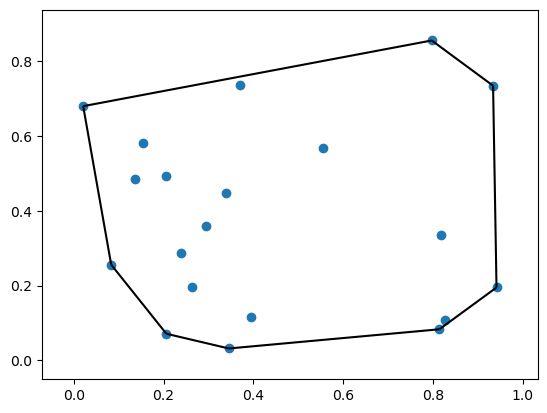

In [9]:
convex_hull_plot_2d(hull)
plt.show()